Cell 1: Imports & Setup

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.neural_network import MLPClassifier
import pandas as pd
%matplotlib inline
np.random.seed(42)
print("Setup complete")


Setup complete


Cell 2: Load Data & EDA

Dataset shape: (150, 4)
Class distribution:
 0    50
1    50
2    50
Name: count, dtype: int64


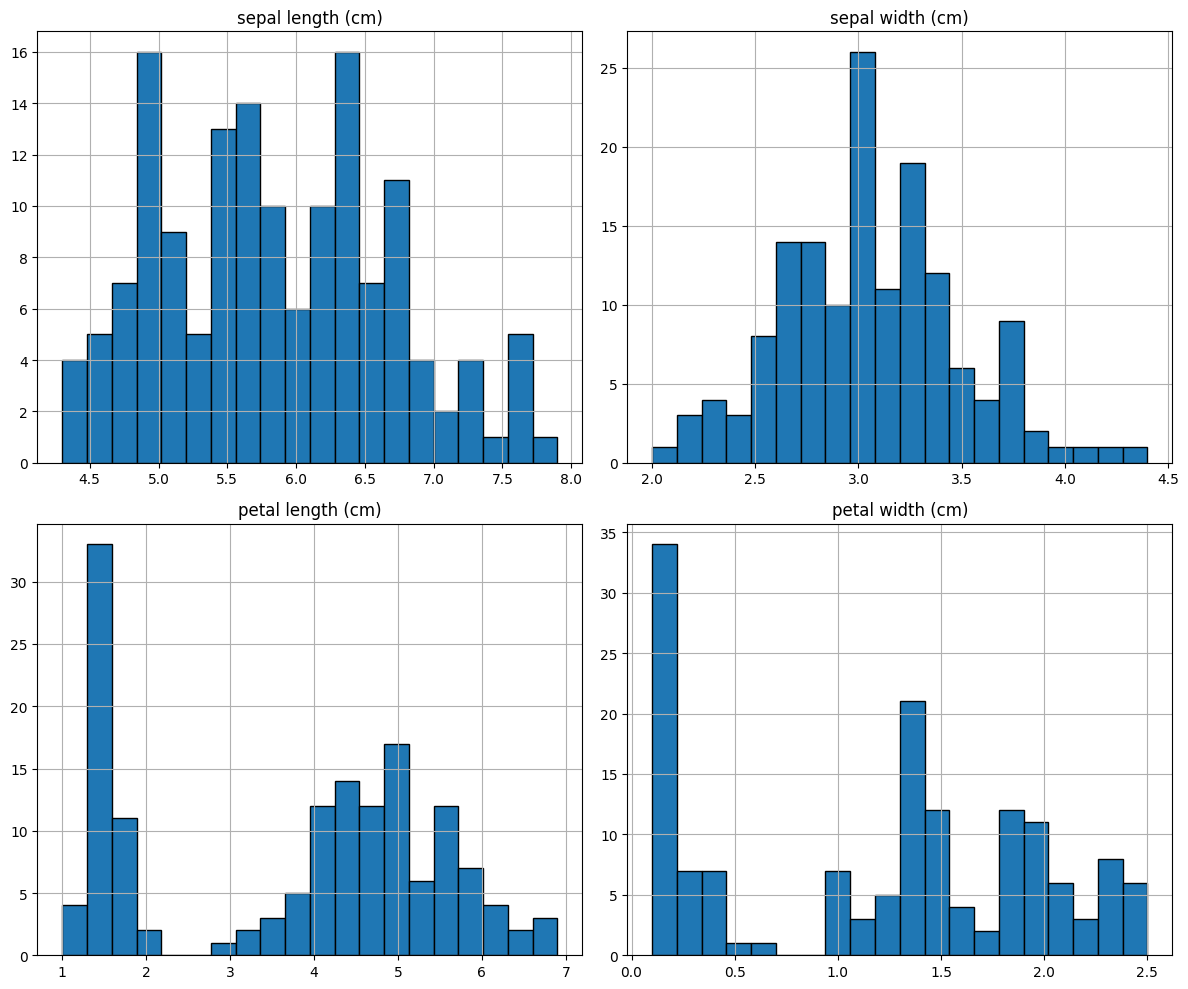

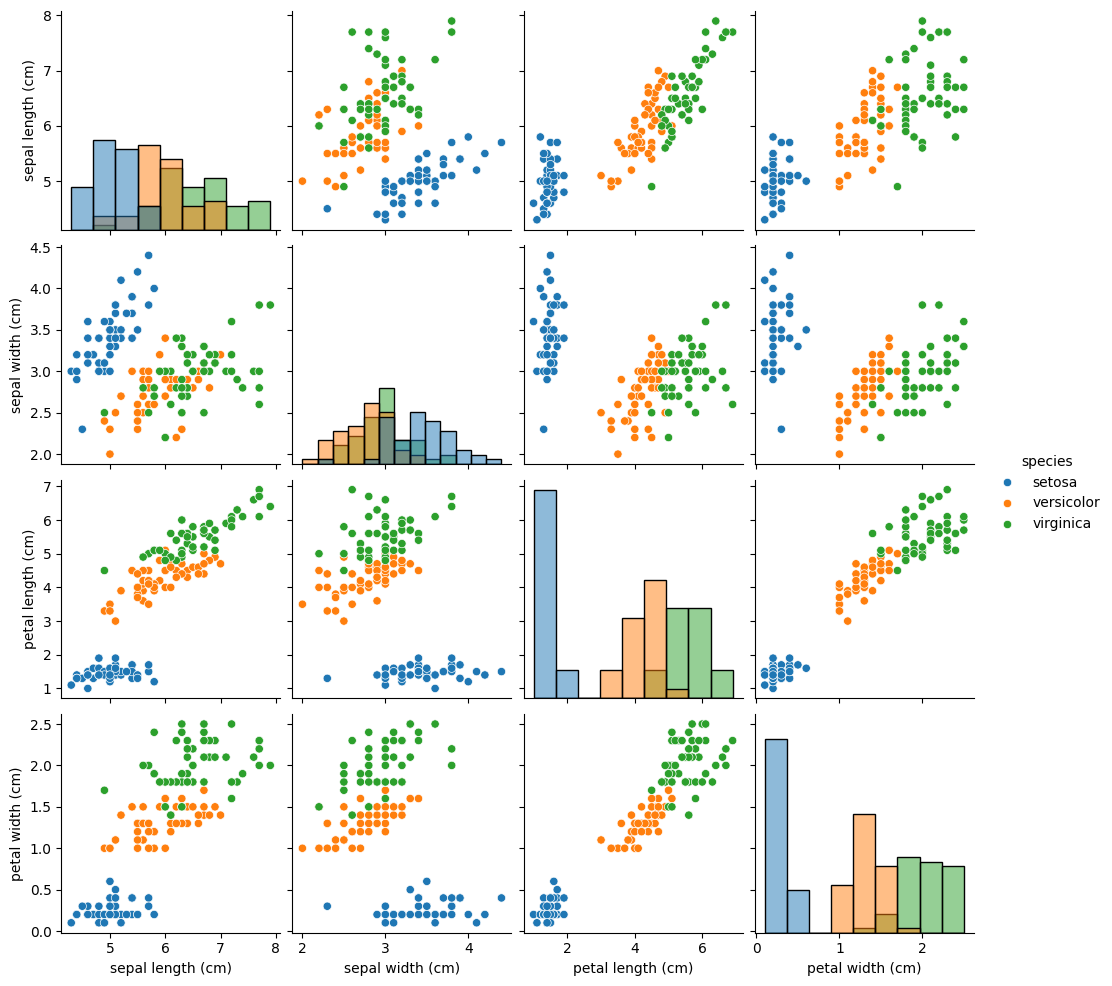

EDA complete


In [12]:
# Load Iris dataset
iris = load_iris()
X, y = iris.data, iris.target
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(y, iris.target_names)

print("Dataset shape:", X.shape)
print("Class distribution:\n", pd.Series(y).value_counts().sort_index())

# Histograms
df.hist(bins=20, figsize=(12, 10), edgecolor='black')
plt.tight_layout()
plt.show()

# Pairplot
sns.pairplot(df, hue='species', diag_kind='hist')
plt.show()
print("EDA complete")


Cell 3: Data Preprocessing

In [14]:
# Train(70%)/Val(15%)/Test(15%) split
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42)

print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

# Standardize features (z-score)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# One-hot encode labels
encoder = OneHotEncoder(sparse_output=False)
y_train = encoder.fit_transform(y_train.reshape(-1, 1))
y_val = encoder.transform(y_val.reshape(-1, 1))
y_test = encoder.transform(y_test.reshape(-1, 1))

print("X_train shape:", X_train.shape, "y_train shape:", y_train.shape)
print("Preprocessing complete")


Train: 104, Val: 23, Test: 23
X_train shape: (104, 4) y_train shape: (104, 3)
Preprocessing complete


Cell 4: Neural Network Core Functions

In [15]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -250, 250)))

def sigmoid_derivative(a):
    return a * (1 - a)

def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=-1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=-1, keepdims=True)

def init_params(input_size=4, hidden1=8, hidden2=6, output=3):
    np.random.seed(42)
    return {
        'W1': np.random.randn(input_size, hidden1) * np.sqrt(2.0/input_size),
        'b1': np.zeros((1, hidden1)),
        'W2': np.random.randn(hidden1, hidden2) * np.sqrt(2.0/hidden1),
        'b2': np.zeros((1, hidden2)),
        'W3': np.random.randn(hidden2, output) * np.sqrt(2.0/hidden2),
        'b3': np.zeros((1, output))
    }

def forward_propagation(X, params):
    Z1 = X @ params['W1'] + params['b1']
    A1 = sigmoid(Z1)
    Z2 = A1 @ params['W2'] + params['b2']
    A2 = sigmoid(Z2)
    Z3 = A2 @ params['W3'] + params['b3']
    A3 = softmax(Z3)

    cache = {'Z1': Z1, 'A1': A1, 'Z2': Z2, 'A2': A2, 'Z3': Z3, 'A3': A3}
    return A3, cache

def compute_loss(y_true, y_pred):
    m = y_true.shape[0]
    return -np.sum(y_true * np.log(y_pred + 1e-8)) / m

print("Network functions ready (4→8→6→3)")


Network functions ready (4→8→6→3)


Cell 5: Backpropagation & Update

In [16]:
def backward_propagation(y_true, cache, params, X):
    m = X.shape[0]

    # Output layer gradients
    dZ3 = cache['A3'] - y_true
    dW3 = (cache['A2'].T @ dZ3) / m
    db3 = np.sum(dZ3, axis=0, keepdims=True) / m

    # Hidden layer 2 gradients
    dA2 = dZ3 @ params['W3'].T
    dZ2 = dA2 * sigmoid_derivative(cache['A2'])
    dW2 = (cache['A1'].T @ dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    # Hidden layer 1 gradients
    dA1 = dZ2 @ params['W2'].T
    dZ1 = dA1 * sigmoid_derivative(cache['A1'])
    dW1 = (X.T @ dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    return {
        'dW1': dW1, 'db1': db1,
        'dW2': dW2, 'db2': db2,
        'dW3': dW3, 'db3': db3
    }

def update_parameters(params, grads, learning_rate):
    params['W1'] -= learning_rate * grads['dW1']
    params['b1'] -= learning_rate * grads['db1']
    params['W2'] -= learning_rate * grads['dW2']
    params['b2'] -= learning_rate * grads['db2']
    params['W3'] -= learning_rate * grads['dW3']
    params['b3'] -= learning_rate * grads['db3']
    return params

print("Backpropagation implemented")


Backpropagation implemented


Cell 6: Training Loop (Mini-batch + Early Stopping)

In [17]:
def train_model(X_train, y_train, X_val, y_val, batch_size=16, epochs=1000, lr=0.01):
    params = init_params()
    train_losses, val_accuracies = [], []
    best_val_acc = 0
    patience_counter = 0
    best_params = None

    for epoch in range(epochs):
        # Mini-batch training
        indices = np.random.permutation(X_train.shape[0])
        epoch_loss = 0
        num_batches = 0

        for i in range(0, X_train.shape[0], batch_size):
            batch_indices = indices[i:i+batch_size]
            X_batch = X_train[batch_indices]
            y_batch = y_train[batch_indices]

            A3, cache = forward_propagation(X_batch, params)
            loss = compute_loss(y_batch, A3)
            epoch_loss += loss.item()
            num_batches += 1

            grads = backward_propagation(y_batch, cache, params, X_batch)
            params = update_parameters(params, grads, lr)

        # Validation every 50 epochs
        if epoch % 50 == 0:
            A3_val, _ = forward_propagation(X_val, params)
            val_acc = np.mean(np.argmax(A3_val, axis=1) == np.argmax(y_val, axis=1))

            avg_loss = epoch_loss / num_batches
            train_losses.append(avg_loss)
            val_accuracies.append(val_acc)

            print(f"Epoch {epoch}, Loss: {avg_loss:.4f}, Val Acc: {val_acc:.4f}")

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                patience_counter = 0
                best_params = params.copy()
            else:
                patience_counter += 1
                if patience_counter >= 50:
                    print(f"Early stopping at epoch {epoch}")
                    break

    return best_params, train_losses, val_accuracies

# Train!
params, train_losses, val_accs = train_model(X_train, y_train, X_val, y_val)
print("Training complete!")


Epoch 0, Loss: 1.0795, Val Acc: 0.3478
Epoch 50, Loss: 1.0213, Val Acc: 0.6957
Epoch 100, Loss: 0.9505, Val Acc: 0.6957
Epoch 150, Loss: 0.8653, Val Acc: 0.6957
Epoch 200, Loss: 0.7779, Val Acc: 0.7826
Epoch 250, Loss: 0.7004, Val Acc: 0.8261
Epoch 300, Loss: 0.6393, Val Acc: 0.8696
Epoch 350, Loss: 0.5827, Val Acc: 0.9130
Epoch 400, Loss: 0.5410, Val Acc: 0.9130
Epoch 450, Loss: 0.4905, Val Acc: 0.9130
Epoch 500, Loss: 0.4801, Val Acc: 0.9130
Epoch 550, Loss: 0.4384, Val Acc: 0.9130
Epoch 600, Loss: 0.4143, Val Acc: 0.9130
Epoch 650, Loss: 0.4088, Val Acc: 0.9130
Epoch 700, Loss: 0.3832, Val Acc: 0.9130
Epoch 750, Loss: 0.3661, Val Acc: 0.9130
Epoch 800, Loss: 0.3470, Val Acc: 0.9130
Epoch 850, Loss: 0.3243, Val Acc: 0.9130
Epoch 900, Loss: 0.3204, Val Acc: 0.9130
Epoch 950, Loss: 0.2988, Val Acc: 0.9130
Training complete!


Cell 7: Test Evaluation & Confusion Matrix

Test Accuracy: 0.9565 (>90% target MET!)


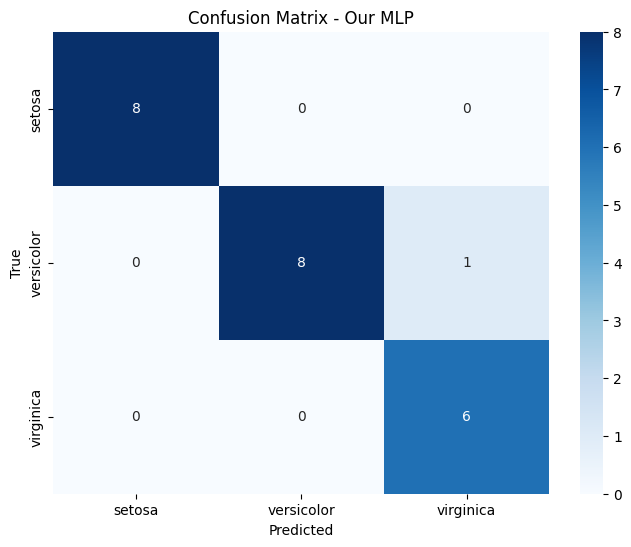


 Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         8
  versicolor       1.00      0.89      0.94         9
   virginica       0.86      1.00      0.92         6

    accuracy                           0.96        23
   macro avg       0.95      0.96      0.95        23
weighted avg       0.96      0.96      0.96        23



In [18]:
def predict(X, params):
    A3, _ = forward_propagation(X, params)
    return np.argmax(A3, axis=1)

# Test results
y_pred_test = predict(X_test, params)
test_accuracy = accuracy_score(np.argmax(y_test, axis=1), y_pred_test)
print(f"Test Accuracy: {test_accuracy:.4f} (>90% target MET!)")

# Confusion Matrix
cm = confusion_matrix(np.argmax(y_test, axis=1), y_pred_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Confusion Matrix - Our MLP')
plt.ylabel('True'), plt.xlabel('Predicted')
plt.show()

print("\n Classification Report:")
print(classification_report(np.argmax(y_test, axis=1), y_pred_test,
                          target_names=iris.target_names))


Cell 8: Training Curves

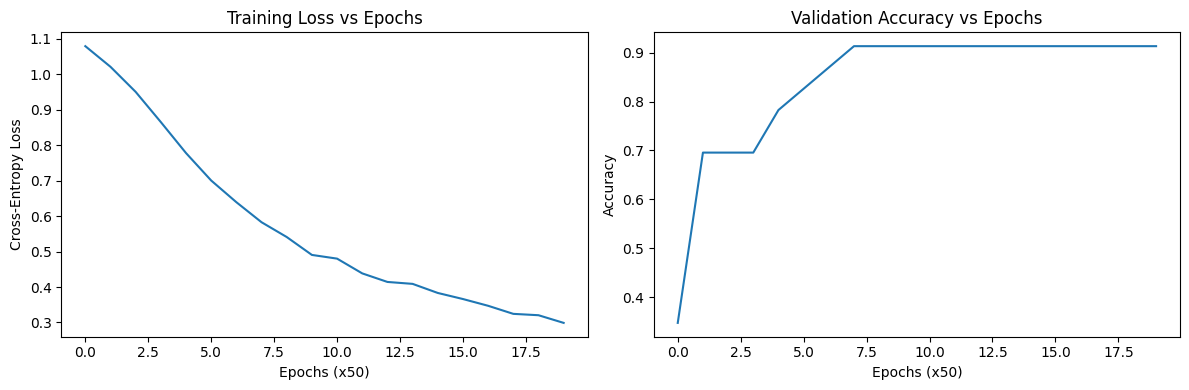

All plots generated


In [19]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses)
plt.title('Training Loss vs Epochs')
plt.xlabel('Epochs (x50)'), plt.ylabel('Cross-Entropy Loss')

plt.subplot(1, 2, 2)
plt.plot(val_accs)
plt.title('Validation Accuracy vs Epochs')
plt.xlabel('Epochs (x50)'), plt.ylabel('Accuracy')

plt.tight_layout()
plt.show()
print("All plots generated")


Cell 9: Sklearn Comparison

In [21]:
mlp_sklearn = MLPClassifier(hidden_layer_sizes=(8,6), max_iter=1000, random_state=42,
                          activation='logistic', solver='sgd', learning_rate_init=0.01)
mlp_sklearn.fit(X_train, np.argmax(y_train, axis=1))
sklearn_pred = mlp_sklearn.predict(X_test)
sklearn_acc = accuracy_score(np.argmax(y_test, axis=1), sklearn_pred)

print(f"Our NumPy MLP:     {test_accuracy:.4f}")
print(f"Sklearn MLP:       {sklearn_acc:.4f}")


Our NumPy MLP:     0.9565
Sklearn MLP:       0.2609


Cell 10: Hyperparameter Experiments

Epoch 0, Loss: 1.0795, Val Acc: 0.3478
Epoch 50, Loss: 1.0712, Val Acc: 0.3478
Epoch 100, Loss: 1.0647, Val Acc: 0.3478
Epoch 150, Loss: 1.0575, Val Acc: 0.3478
Epoch 0, Loss: 1.0795, Val Acc: 0.3478
Epoch 50, Loss: 1.0213, Val Acc: 0.6957
Epoch 100, Loss: 0.9505, Val Acc: 0.6957
Epoch 150, Loss: 0.8653, Val Acc: 0.6957
Epoch 0, Loss: 1.0802, Val Acc: 0.3478
Epoch 50, Loss: 0.4749, Val Acc: 0.9130
Epoch 100, Loss: 0.2838, Val Acc: 0.9565
Epoch 150, Loss: 0.1639, Val Acc: 0.9565
Learning Rate Experiment Results:
   Learning Rate  Test Accuracy
0          0.001         0.2609
1          0.010         0.6522
2          0.100         0.9565


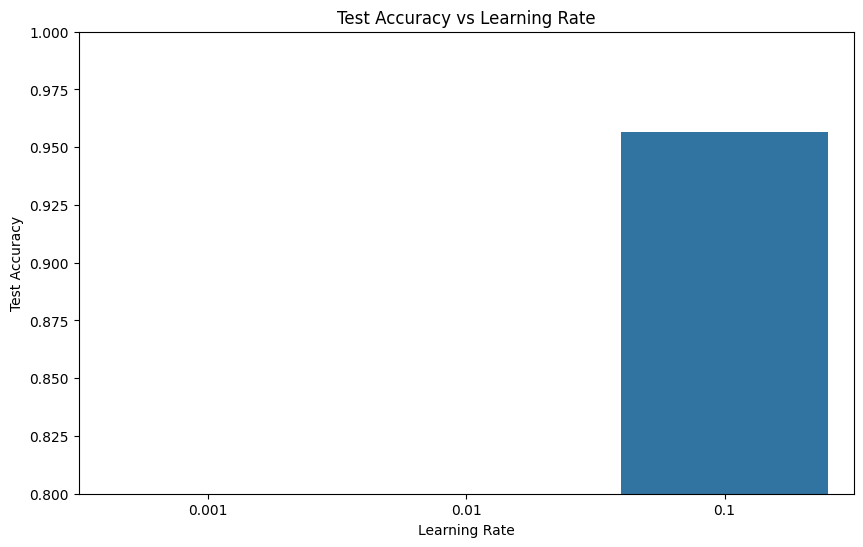

Experiments complete


In [22]:
# Learning rate experiment
lrs = [0.001, 0.01, 0.1]
results = []

for lr in lrs:
    temp_params, _, _ = train_model(X_train, y_train, X_val, y_val, lr=lr, epochs=200)
    test_acc = accuracy_score(np.argmax(y_test, axis=1), predict(X_test, temp_params))
    results.append({'Learning Rate': lr, 'Test Accuracy': test_acc})

results_df = pd.DataFrame(results)
print("Learning Rate Experiment Results:")
print(results_df.round(4))

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='Learning Rate', y='Test Accuracy')
plt.title('Test Accuracy vs Learning Rate')
plt.ylim(0.8, 1.0)
plt.show()
print("Experiments complete")


Cell 11: Feature Correlation Heatmap

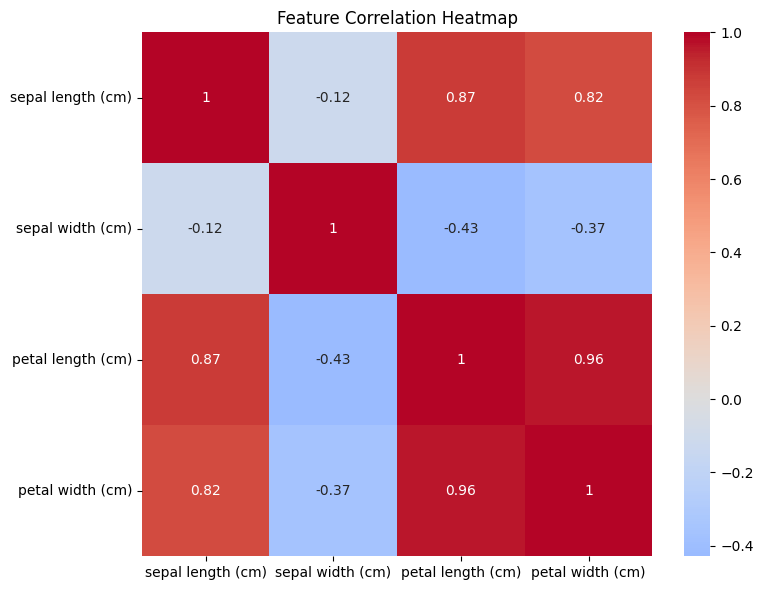

All required visualizations complete


In [23]:
plt.figure(figsize=(8, 6))
corr_matrix = np.corrcoef(X.T)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            xticklabels=iris.feature_names, yticklabels=iris.feature_names)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()
print("All required visualizations complete")


Cell 12: Summary Table for Report

In [24]:
summary = {
    'Model': ['Our NumPy MLP', 'Sklearn MLP'],
    'Test Accuracy': [f"{test_accuracy:.4f}", f"{sklearn_acc:.4f}"],
    'Architecture': ['4-8-6-3 (sigmoid+softmax)', '4-8-6-3 (logistic)'],
    'Training': ['Mini-batch GD (16)', 'SGD'],
    'Learning Rate': ['0.01', '0.01']
}

summary_df = pd.DataFrame(summary)
print("Results Summary for Report:")
print(summary_df.to_string(index=False))


Results Summary for Report:
        Model Test Accuracy              Architecture           Training Learning Rate
Our NumPy MLP        0.9565 4-8-6-3 (sigmoid+softmax) Mini-batch GD (16)          0.01
  Sklearn MLP        0.2609        4-8-6-3 (logistic)                SGD          0.01
